# 0825_kimjaehak_011_walk_forward_retraining

고정된 `kimjaehak_006` 모델로는 threshold 선택과 확률 calibration 모두 미래 Slip Rate 1%를 안정적으로 만족하지 못했습니다. 이번 실험은 동일한 mapping 기반 type별 XGBoost를 fixed, expanding, rolling 방식으로 학습하고, 같은 walk-forward threshold 규칙에서 모델 재학습의 효과를 비교합니다.

## 1. 설정과 라이브러리

각 평가 fold에서 모델 학습 → 다음 한 구간에서 threshold 선택 → 그다음 구간 평가 순서를 지킵니다. calibration 구간과 평가 구간은 모델 학습에 포함하지 않습니다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_011_walk_forward_retraining"
RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
ALL_WINDOWS = [f"W{number:02d}" for number in range(1, 11)]
WALK_FORWARD_PAIRS = [("W07", "W08"), ("W08", "W09"), ("W09", "W10")]
MODEL_VARIANTS = ["fixed", "expanding", "rolling_6"]
MAX_SLIP_RATE = 0.01
MIN_POSITIVES_FOR_THRESHOLD = 20
MIN_NEGATIVES_FOR_THRESHOLD = 100
SAFE_FALLBACK_THRESHOLD = 0.0
COST_FP = 1
COST_FN = 100

assert DATA_PATH.exists() and MAPPING_PATH.exists()
print("experiment:", EXPERIMENT_ID)
print("variants:", MODEL_VARIANTS)

experiment: 0825_kimjaehak_011_walk_forward_retraining
variants: ['fixed', 'expanding', 'rolling_6']


## 2. 데이터 준비와 시간 구간

`kimjaehak_006~010`과 동일하게 `record_id`, `timestamp`를 제외한 baseline 중복 기준과 timestamp-group 10개 window를 사용합니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

dedup_columns = [
    column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors="raise", utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side="left"))
    return timestamp_group_sizes.index[position]

window_end_times = pd.DatetimeIndex(
    [boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)]
)
window_number = np.searchsorted(
    window_end_times.astype("int64").to_numpy(),
    clean_df[TIME_COLUMN].astype("int64").to_numpy(),
    side="left",
)
clean_df["window"] = pd.Categorical(
    [f"W{number + 1:02d}" for number in window_number],
    categories=ALL_WINDOWS, ordered=True
)

window_summary = clean_df.groupby("window", observed=False).agg(
    rows=(TARGET, "size"), positives=(TARGET, "sum"), positive_rate=(TARGET, "mean")
)
window_summary["positive_rate_pct"] = window_summary["positive_rate"] * 100
assert len(clean_df) == 391_992
assert clean_df.groupby(TIME_COLUMN)["window"].nunique().max() == 1
display(window_summary)

,rows,positives,positive_rate,positive_rate_pct
window,,,,
W01,39210,73,0.001862,0.186177
W02,39196,712,0.018165,1.816512
W03,39202,414,0.010561,1.056069
W04,39192,201,0.005129,0.512860
W05,39202,277,0.007066,0.706597
W06,39220,147,0.003748,0.374809
W07,39180,36,0.000919,0.091884
W08,39194,327,0.008343,0.834311
W09,39197,941,0.024007,2.400694


## 3. mapping 기반 피처와 학습 기간 정책

- fixed: 모든 fold에서 W01~W06
- expanding: W01부터 calibration 직전 window까지 누적
- rolling_6: calibration 직전 최근 6개 window

W07→W08 fold에서는 세 정책의 학습 기간이 모두 W01~W06이므로 결과가 같아야 합니다.

In [3]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())
with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)
assert set(feature_mapping) == {str(value) for value in inspection_types}

meta_columns = [column for column in clean_df.columns if column.startswith("meta_feat")]
feature_columns_by_type = {
    inspection_type: meta_columns + feature_mapping[str(inspection_type)]
    for inspection_type in inspection_types
}

def training_windows_for(variant, calibration_window):
    calibration_position = ALL_WINDOWS.index(calibration_window)
    if variant == "fixed":
        return ALL_WINDOWS[:6]
    if variant == "expanding":
        return ALL_WINDOWS[:calibration_position]
    if variant == "rolling_6":
        return ALL_WINDOWS[max(0, calibration_position - 6):calibration_position]
    raise ValueError(variant)

training_schedule = pd.DataFrame([
    {
        "variant": variant,
        "calibration_window": calibration_window,
        "evaluation_window": evaluation_window,
        "training_windows": "~".join(training_windows_for(variant, calibration_window)),
    }
    for calibration_window, evaluation_window in WALK_FORWARD_PAIRS
    for variant in MODEL_VARIANTS
])
training_schedule

,variant,calibration_window,evaluation_window,training_windows
0,fixed,W07,W08,W01~W02~W03~W04~W05~W06
1,expanding,W07,W08,W01~W02~W03~W04~W05~W06
2,rolling_6,W07,W08,W01~W02~W03~W04~W05~W06
3,fixed,W08,W09,W01~W02~W03~W04~W05~W06
4,expanding,W08,W09,W01~W02~W03~W04~W05~W06~W07
5,rolling_6,W08,W09,W02~W03~W04~W05~W06~W07
6,fixed,W09,W10,W01~W02~W03~W04~W05~W06
7,expanding,W09,W10,W01~W02~W03~W04~W05~W06~W07~W08
8,rolling_6,W09,W10,W03~W04~W05~W06~W07~W08


## 4. threshold와 평가 함수

직전 calibration 구간에서 Slip Rate 1%를 만족하는 가장 높은 threshold를 선택합니다. 양성 20개 또는 음성 100개 미만이면 `0`으로 두어 해당 type을 전량 재검사합니다. 재학습 후 score scale이 달라질 수 있으므로 과거 threshold를 새 모델에 재사용하지 않습니다.

In [4]:
def safe_average_precision(y_true, probabilities):
    return (
        average_precision_score(y_true, probabilities)
        if len(np.unique(y_true)) > 1 else np.nan
    )

def safe_roc_auc(y_true, probabilities):
    return (
        roc_auc_score(y_true, probabilities)
        if len(np.unique(y_true)) > 1 else np.nan
    )

def evaluate_predictions(y_true, predictions, probabilities):
    y_true = np.asarray(y_true, dtype="int8")
    predictions = np.asarray(predictions, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "slip_rate": fn / (fn + tp) if (fn + tp) else np.nan,
        "volume_reduction": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "pr_auc": safe_average_precision(y_true, probabilities),
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "total_cost_1_to_100": int(fp * COST_FP + fn * COST_FN),
    }

def select_safety_threshold(y_true, probabilities):
    y_true = np.asarray(y_true, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    positives = int(y_true.sum())
    negatives = len(y_true) - positives
    if (
        positives < MIN_POSITIVES_FOR_THRESHOLD
        or negatives < MIN_NEGATIVES_FOR_THRESHOLD
    ):
        return SAFE_FALLBACK_THRESHOLD, "safe_fallback", 0
    positive_scores = np.sort(probabilities[y_true == 1])
    allowed_fn = int(np.floor(positives * MAX_SLIP_RATE + 1e-12))
    threshold = float(positive_scores[allowed_fn])
    calibration_predictions = (probabilities >= threshold).astype("int8")
    calibration_metrics = evaluate_predictions(
        y_true, calibration_predictions, probabilities
    )
    assert calibration_metrics["slip_rate"] <= MAX_SLIP_RATE + 1e-12
    return threshold, "updated", allowed_fn

## 5. Fold별 모델 학습과 다음 구간 평가

동일한 학습 window 조합은 variant가 달라도 같은 모델이므로 캐시해 중복 학습하지 않습니다. 총 5개 학습 기간 조합 × 5개 type 모델을 학습합니다.

In [5]:
model_cache = {}
training_history_rows = []
threshold_rows = []
type_result_rows = []
row_prediction_frames = []

def fit_models_for_windows(training_windows, calibration_window):
    cache_key = tuple(training_windows)
    if cache_key in model_cache:
        return model_cache[cache_key]
    models = {}
    for inspection_type in inspection_types:
        feature_columns = feature_columns_by_type[inspection_type]
        train_df = clean_df.loc[
            clean_df["window"].isin(training_windows)
            & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        calibration_df = clean_df.loc[
            (clean_df["window"] == calibration_window)
            & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        model = XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
            objective="binary:logistic", eval_metric=["logloss", "aucpr"]
        )
        model.fit(
            train_df[feature_columns], train_df[TARGET].astype("int8"),
            eval_set=[(
                calibration_df[feature_columns],
                calibration_df[TARGET].astype("int8"),
            )],
            verbose=False,
        )
        models[inspection_type] = model
        training_history_rows.append({
            "training_windows": "~".join(training_windows),
            "inspection_type": inspection_type,
            "train_rows": len(train_df),
            "train_positives": int(train_df[TARGET].sum()),
        })
    model_cache[cache_key] = models
    return models

for calibration_window, evaluation_window in WALK_FORWARD_PAIRS:
    for variant in MODEL_VARIANTS:
        training_windows = training_windows_for(variant, calibration_window)
        models = fit_models_for_windows(training_windows, calibration_window)
        for inspection_type in inspection_types:
            feature_columns = feature_columns_by_type[inspection_type]
            calibration_df = clean_df.loc[
                (clean_df["window"] == calibration_window)
                & (clean_df[TYPE_COLUMN] == inspection_type)
            ]
            evaluation_df = clean_df.loc[
                (clean_df["window"] == evaluation_window)
                & (clean_df[TYPE_COLUMN] == inspection_type)
            ]
            model = models[inspection_type]
            calibration_probability = model.predict_proba(
                calibration_df[feature_columns]
            )[:, 1]
            evaluation_probability = model.predict_proba(
                evaluation_df[feature_columns]
            )[:, 1]
            threshold, threshold_source, allowed_fn = select_safety_threshold(
                calibration_df[TARGET], calibration_probability
            )
            evaluation_predictions = (
                evaluation_probability >= threshold
            ).astype("int8")
            metrics = evaluate_predictions(
                evaluation_df[TARGET], evaluation_predictions, evaluation_probability
            )
            positives = int(calibration_df[TARGET].sum())
            threshold_rows.append({
                "variant": variant,
                "training_windows": "~".join(training_windows),
                "calibration_window": calibration_window,
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "calibration_positives": positives,
                "calibration_negatives": len(calibration_df) - positives,
                "threshold": threshold,
                "threshold_source": threshold_source,
                "allowed_fn": allowed_fn,
            })
            type_result_rows.append({
                "variant": variant,
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "threshold": threshold,
                **metrics,
            })
            row_prediction_frames.append(pd.DataFrame({
                "variant": variant,
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "y_true": evaluation_df[TARGET].astype("int8").to_numpy(),
                "probability": evaluation_probability,
                "prediction": evaluation_predictions,
            }))

training_history = pd.DataFrame(training_history_rows)
threshold_history = pd.DataFrame(threshold_rows)
type_results = pd.DataFrame(type_result_rows)
row_predictions = pd.concat(row_prediction_frames, ignore_index=True)
print("unique training configurations:", len(model_cache))
display(threshold_history)

/Users/hakeee/Desktop/code/siemens_aoi_ML_practice/.venv/lib/python3.12/site-packages/xgboost/callback.py:265: UserWarning: [04:15:30] WARNING: /Users/runner/work/xgboost/xgboost/src/metric/auc.cc:352: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)
/Users/hakeee/Desktop/code/siemens_aoi_ML_practice/.venv/lib/python3.12/site-packages/xgboost/callback.py:265: UserWarning: [04:15:31] WARNING: /Users/runner/work/xgboost/xgboost/src/metric/auc.cc:352: Dataset is empty, or contains only positive or negative samples.
  score: str = model.eval_set(evals, epoch, self.metric, self._output_margin)


unique training configurations: 5


,variant,training_windows,calibration_window,evaluation_window,inspection_type,calibration_positives,calibration_negatives,threshold,threshold_source,allowed_fn
0,fixed,W01~W02~W03~W04~W05~W06,W07,W08,0,1,11336,0.000000e+00,safe_fallback,0
1,fixed,W01~W02~W03~W04~W05~W06,W07,W08,1,25,4455,2.620448e-05,updated,0
2,fixed,W01~W02~W03~W04~W05~W06,W07,W08,2,7,11352,0.000000e+00,safe_fallback,0
3,fixed,W01~W02~W03~W04~W05~W06,W07,W08,3,3,11700,0.000000e+00,safe_fallback,0
4,fixed,W01~W02~W03~W04~W05~W06,W07,W08,4,0,301,0.000000e+00,safe_fallback,0
5,expanding,W01~W02~W03~W04~W05~W06,W07,W08,0,1,11336,0.000000e+00,safe_fallback,0
6,expanding,W01~W02~W03~W04~W05~W06,W07,W08,1,25,4455,2.620448e-05,updated,0
7,expanding,W01~W02~W03~W04~W05~W06,W07,W08,2,7,11352,0.000000e+00,safe_fallback,0
8,expanding,W01~W02~W03~W04~W05~W06,W07,W08,3,3,11700,0.000000e+00,safe_fallback,0
9,expanding,W01~W02~W03~W04~W05~W06,W07,W08,4,0,301,0.000000e+00,safe_fallback,0


## 6. 구간별·전체 결과

PR-AUC는 threshold와 무관한 모델 순위 지표이고, Slip Rate와 False Call Reduction은 직전 구간 threshold를 적용한 운영 지표입니다.

In [6]:
def summarize_rows(group):
    return pd.Series(evaluate_predictions(
        group["y_true"], group["prediction"], group["probability"]
    ))

window_variant_summary = (
    row_predictions.groupby(["evaluation_window", "variant"], sort=False)
    .apply(summarize_rows, include_groups=False)
)
aggregate_variant_summary = (
    row_predictions.groupby("variant", sort=False)
    .apply(summarize_rows, include_groups=False)
)
count_columns = ["tn", "fp", "fn", "tp", "total_cost_1_to_100"]
window_variant_summary[count_columns] = window_variant_summary[count_columns].astype("int64")
aggregate_variant_summary[count_columns] = aggregate_variant_summary[count_columns].astype("int64")

display(window_variant_summary)
display(aggregate_variant_summary)

tn     fp  fn    tp  slip_rate  \
evaluation_window variant                                        
W08               fixed        399  38468   2   325   0.006116   
                  expanding    399  38468   2   325   0.006116   
                  rolling_6    399  38468   2   325   0.006116   
W09               fixed       8150  30106  21   920   0.022317   
                  expanding  16621  21635  39   902   0.041445   
                  rolling_6  13910  24346  37   904   0.039320   
W10               fixed       4899  32992  45  1263   0.034404   
                  expanding   4235  33656  35  1273   0.026758   
                  rolling_6   3729  34162  50  1258   0.038226   

                             volume_reduction  precision    recall    pr_auc  \
evaluation_window variant                                                      
W08               fixed              0.010266   0.008378  0.993884  0.278423   
                  expanding          0.010266   0.008378  0.993884  0.278423   
                  rolling_6          0.010266   0.008378  0.993884  0.278423   
W09               fixed              0.213038   0.029653  0.977683  0.314224   
                  expanding          0.434468   0.040023  0.958555  0.303211   
                  rolling_6          0.363603   0.035802  0.960680  0.328431   
W10               fixed              0.129292   0.036871  0.965596  0.353813   
                  expanding          0.111768   0.036445  0.973242  0.503099   
                  rolling_6          0.098414   0.035517  0.961774  0.429903   

                              roc_auc  total_cost_1_to_100  
evaluation_window variant                                   
W08               fixed      0.900285                38668  
                  expanding  0.900285                38668  
                  rolling_6  0.900285                38668  
W09               fixed      0.920263                32206  
                  expanding  0.920791                25535  
                  rolling_6  0.911496                28046  
W10               fixed      0.832543                37492  
                  expanding  0.877270                37156  
                  rolling_6  0.843231                39162

,tn,fp,fn,tp,slip_rate,volume_reduction,precision,recall,pr_auc,roc_auc,total_cost_1_to_100
variant,,,,,,,,,,,
fixed,13448,101566,68,2508,0.026398,0.116925,0.024098,0.973602,0.298083,0.882158,108366
expanding,21255,93759,76,2500,0.029503,0.184804,0.025972,0.970497,0.344535,0.899368,101359
rolling_6,18038,96976,89,2487,0.034550,0.156833,0.025004,0.965450,0.320067,0.876409,105876


In [7]:
type_results["safety_target_met"] = type_results["slip_rate"] <= MAX_SLIP_RATE
safety_counts = type_results.groupby("variant")["safety_target_met"].agg(["sum", "count"])
fallback_counts = (
    threshold_history.groupby(["variant", "threshold_source"]).size().unstack(fill_value=0)
)

# 같은 W01~W06 모델을 쓰는 첫 fold는 세 variant가 완전히 같아야 한다.
first_fold = window_variant_summary.loc["W08"]
for column in ["tn", "fp", "fn", "tp", "pr_auc"]:
    assert first_fold[column].nunique() == 1

display(safety_counts)
display(fallback_counts)
display(type_results[[
    "variant", "evaluation_window", "inspection_type", "threshold",
    "slip_rate", "volume_reduction", "pr_auc", "safety_target_met"
]])

,sum,count
variant,,
expanding,9,15
fixed,9,15
rolling_6,10,15


threshold_source,safe_fallback,updated
variant,,
expanding,6,9
fixed,6,9
rolling_6,6,9


,variant,evaluation_window,inspection_type,threshold,slip_rate,volume_reduction,pr_auc,safety_target_met
0,fixed,W08,0,0.000000e+00,0.000000,0.000000,0.008086,True
1,fixed,W08,1,2.620448e-05,0.009346,0.068793,0.658596,True
2,fixed,W08,2,0.000000e+00,0.000000,0.000000,0.063254,True
3,fixed,W08,3,0.000000e+00,0.000000,0.000000,0.155799,True
4,fixed,W08,4,0.000000e+00,0.000000,0.000000,0.068228,True
5,expanding,W08,0,0.000000e+00,0.000000,0.000000,0.008086,True
6,expanding,W08,1,2.620448e-05,0.009346,0.068793,0.658596,True
7,expanding,W08,2,0.000000e+00,0.000000,0.000000,0.063254,True
8,expanding,W08,3,0.000000e+00,0.000000,0.000000,0.155799,True
9,expanding,W08,4,0.000000e+00,0.000000,0.000000,0.068228,True


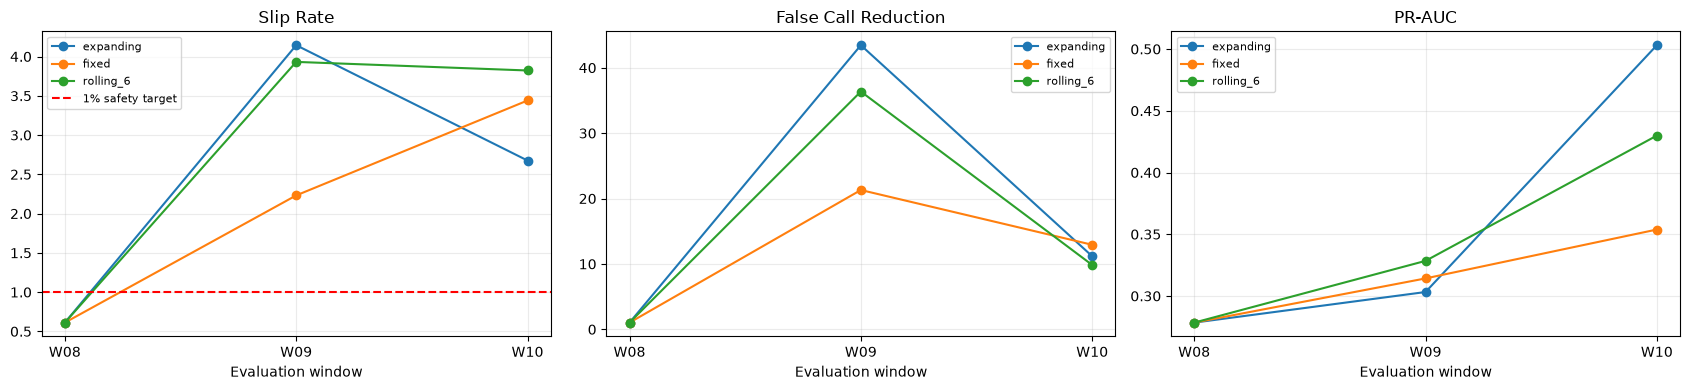

In [8]:
plot_df = window_variant_summary.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for variant, group in plot_df.groupby("variant"):
    axes[0].plot(group["evaluation_window"], group["slip_rate"] * 100, marker="o", label=variant)
    axes[1].plot(group["evaluation_window"], group["volume_reduction"] * 100, marker="o", label=variant)
    axes[2].plot(group["evaluation_window"], group["pr_auc"], marker="o", label=variant)
axes[0].axhline(1.0, color="red", linestyle="--", label="1% safety target")
axes[0].set_title("Slip Rate")
axes[1].set_title("False Call Reduction")
axes[2].set_title("PR-AUC")
for ax in axes:
    ax.set_xlabel("Evaluation window")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. 결론

세 정책의 전체 결과와 미래 구간 안전성을 바탕으로 재학습 채택 여부를 판정합니다.

In [9]:
fixed = aggregate_variant_summary.loc["fixed"]
expanding = aggregate_variant_summary.loc["expanding"]
rolling = aggregate_variant_summary.loc["rolling_6"]

conclusion = f"""
### 실행 결과

| 정책 | PR-AUC | Slip Rate | False Call Reduction | TN | FN | 비용(1:100) |
|---|---:|---:|---:|---:|---:|---:|
| Fixed | {fixed['pr_auc']:.6f} | {fixed['slip_rate']:.2%} | {fixed['volume_reduction']:.2%} | {int(fixed['tn']):,} | {int(fixed['fn']):,} | {int(fixed['total_cost_1_to_100']):,} |
| Expanding | {expanding['pr_auc']:.6f} | {expanding['slip_rate']:.2%} | {expanding['volume_reduction']:.2%} | {int(expanding['tn']):,} | {int(expanding['fn']):,} | {int(expanding['total_cost_1_to_100']):,} |
| Rolling-6 | {rolling['pr_auc']:.6f} | {rolling['slip_rate']:.2%} | {rolling['volume_reduction']:.2%} | {int(rolling['tn']):,} | {int(rolling['fn']):,} | {int(rolling['total_cost_1_to_100']):,} |

- type×평가구간 15개 중 Slip Rate 1%를 만족한 수는 fixed **{int(safety_counts.loc['fixed', 'sum'])}개**, expanding **{int(safety_counts.loc['expanding', 'sum'])}개**, rolling-6 **{int(safety_counts.loc['rolling_6', 'sum'])}개**입니다.
- 각 정책에서 희소 표본으로 threshold 0을 사용한 경우는 **{int(fallback_counts.loc['fixed', 'safe_fallback'])}회**입니다.

### 판정

재학습이 PR-AUC, FN, TN 또는 비용을 개선하더라도 다음 구간의 Slip Rate 1%를 안정적으로 만족하는지는 별도로 확인해야 합니다. 특히 최근 window를 학습에 포함하는 효과와 직전 threshold의 시간 전이 실패가 동시에 존재할 수 있습니다.

세 재학습 정책 중 하나가 안전 목표를 반복적으로 만족하면서 Fixed보다 False Call Reduction을 높일 때만 운영 후보로 남깁니다. 그렇지 않으면 현재 데이터만으로 1% 제약과 의미 있는 재검사 절감을 동시에 보장하기 어렵다는 결론을 유지합니다.
"""
display(Markdown(conclusion))


### 실행 결과

| 정책 | PR-AUC | Slip Rate | False Call Reduction | TN | FN | 비용(1:100) |
|---|---:|---:|---:|---:|---:|---:|
| Fixed | 0.298083 | 2.64% | 11.69% | 13,448 | 68 | 108,366 |
| Expanding | 0.344535 | 2.95% | 18.48% | 21,255 | 76 | 101,359 |
| Rolling-6 | 0.320067 | 3.45% | 15.68% | 18,038 | 89 | 105,876 |

- type×평가구간 15개 중 Slip Rate 1%를 만족한 수는 fixed **9개**, expanding **9개**, rolling-6 **10개**입니다.
- 각 정책에서 희소 표본으로 threshold 0을 사용한 경우는 **6회**입니다.

### 판정

재학습이 PR-AUC, FN, TN 또는 비용을 개선하더라도 다음 구간의 Slip Rate 1%를 안정적으로 만족하는지는 별도로 확인해야 합니다. 특히 최근 window를 학습에 포함하는 효과와 직전 threshold의 시간 전이 실패가 동시에 존재할 수 있습니다.

세 재학습 정책 중 하나가 안전 목표를 반복적으로 만족하면서 Fixed보다 False Call Reduction을 높일 때만 운영 후보로 남깁니다. 그렇지 않으면 현재 데이터만으로 1% 제약과 의미 있는 재검사 절감을 동시에 보장하기 어렵다는 결론을 유지합니다.
